**A Causal Analysis of Online News Polarity on Shares**

*Project in Machine Learning for Econometrics*

Aditya SRIVASTAVA, Yumiao TIAN, Julian KIKUCHI, Rafael MOUROUVIN, Marius LE HÉNAFF

March 24, 2026

This worked starts from a dataset assembled in the 2015 paper " A Proactive Intelligent Decision Support System for Predicting the Popularity of Online News" by  Pereira, F., Machado, P., Costa, E., Cardoso, A.

It gathers information about articles published on the news website Mashable for two years in 2013 and 2014.

From this data, they develop machine learning tools to predict the popularity of articles, measured through the number of shares. They also achieve a platform which proposes authors with marginal modifications to their articles in order to increase their popularity.

Drawing inspiration from their findings, we will explore whether the polarity of articles has a causal effect on the popularity of articles.

After exploratory data analysis motivating the relevance of the question, we use econometrics techniques, double machine learning to study this question.

Contrarily to what could have been thought a priori, we find a negative effect once, and a negative with the other method insignificant effect.

Later, heterogeneity analysis highlights a strong differences in the effect of polarity on shares, considering variation in the level of subjectivity of the articles.

In [1]:
!pip install ucimlrepo
!pip install skrub
!pip install networkx
!pip install pgmpy
!pip install linearmodels
!pip install Stargazer
!pip install econml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 500.5/500.5 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.9/151.9 kB 12.6 MB/s eta 0:00:00
  Attempting uninstall: shap
    Found existing installation: shap 0.51.0
    Uninstalling shap-0.51.0:
      Successfully uninstalled shap-0.51.0


In [2]:
# basic data
import pandas as pd
import numpy as np
import skrub

# stats
from linearmodels.panel import PanelOLS
from scipy import stats
import statsmodels.formula.api as smf
import statsmodels.api as sm

# plotting
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from scipy.stats import uniform, randint

# dag
import networkx as nx
from pgmpy.base.DAG import DAG

# ml
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, LassoCV, LinearRegression
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, KFold, cross_val_predict
from sklearn.base import clone
from sklearn.multioutput import MultiOutputRegressor
from econml.dml import DML
from econml.inference import BootstrapInference

# others
import shap
from stargazer.stargazer import Stargazer
from ucimlrepo import fetch_ucirepo
online_news_popularity = fetch_ucirepo(id=332)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 16
plt.rcParams["xtick.labelsize"] = 14
plt.rcParams["ytick.labelsize"] = 14


# Introducing the dataset



Let us first introduce the dataset and run some sanity checks:
- no null values
- different magnitutes/units in the dataset
    - potential need for standardization, especially for prediction

In [3]:
# data (as pandas dataframes)
X = online_news_popularity.data.features
y = online_news_popularity.data.targets

# metadata
print(online_news_popularity.metadata)

# variable information
print(online_news_popularity.variables)

# column names
df = pd.concat([X, y], axis=1)

print(df.shape)
print(df.columns.tolist())

df.columns = df.columns.str.strip()
print(df.columns.tolist())

{'uci_id': 332, 'name': 'Online News Popularity', 'repository_url': 'https://archive.ics.uci.edu/dataset/332/online+news+popularity', 'data_url': 'https://archive.ics.uci.edu/static/public/332/data.csv', 'abstract': 'This dataset summarizes a heterogeneous set of features about articles published by Mashable in a period of two years. The goal is to predict the number of shares in social networks (popularity).', 'area': 'Business', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 39797, 'num_features': 58, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': [' shares'], 'index_col': ['url'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2015, 'last_updated': 'Thu Feb 15 2024', 'dataset_doi': '10.24432/C5NS3V', 'creators': ['Kelwin Fernandes', 'Pedro Vinagre', 'Paulo Cortez', 'Pedro Sernadela'], 'intro_paper': {'ID': 390, 'type': 'NATIVE', 'title': 'A Proactive Intelligent Decisio

In [4]:
report = skrub.TableReport(df, max_plot_columns=60, max_association_columns = 60)
report

<TableReport: use .open() to display>

One can find column names grouped below so as to understand briefly the sense of the columns.

In [5]:
# get the list of column categories
# =========================
# Words
# =========================
words_cols = [
    "n_tokens_title",
    "n_tokens_content",
    "average_token_length",
    "n_non_stop_words",
    "n_unique_tokens",
    "n_non_stop_unique_tokens",
]

# =========================
# Links
# =========================
links_cols = [
    "num_hrefs",
    "num_self_hrefs",
    "self_reference_min_shares",
    "self_reference_avg_sharess",
    "self_reference_max_shares",
]

# =========================
# Digital Media
# =========================
digital_media_cols = [
    "num_imgs",
    "num_videos",
]

# =========================
# Time
# =========================
time_cols = [
    "weekday_is_monday",
    "weekday_is_tuesday",
    "weekday_is_wednesday",
    "weekday_is_thursday",
    "weekday_is_friday",
    "weekday_is_saturday",
    "weekday_is_sunday",
    "is_weekend",
]

# =========================
# Keywords
# =========================
keywords_cols = [
    "num_keywords",
    # Worst keyword (min/avg/max shares)
    "kw_min_min",
    "kw_min_avg",
    "kw_min_max",
    # Best keyword (min/avg/max shares)
    "kw_max_min",
    "kw_max_avg",
    "kw_max_max",
    # Average keyword (min/avg/max shares)
    "kw_avg_min",
    "kw_avg_avg",
    "kw_avg_max",
]

news_category = [    # Article category (data channel)
    "data_channel_is_lifestyle",
    "data_channel_is_entertainment",
    "data_channel_is_bus",
    "data_channel_is_socmed",
    "data_channel_is_tech",
    "data_channel_is_world"]

# =========================
# Natural Language Processing
# =========================
nlp_cols = [
    # LDA topics
    "LDA_00",
    "LDA_01",
    "LDA_02",
    "LDA_03",
    "LDA_04",
    # Subjectivity
    "global_subjectivity",
    "title_subjectivity",
    "abs_title_subjectivity",
    # Sentiment polarity
    "global_sentiment_polarity",
    "title_sentiment_polarity",
    "abs_title_sentiment_polarity",
    # Positive/negative word rates
    "global_rate_positive_words",
    "global_rate_negative_words",
    "rate_positive_words",
    "rate_negative_words",
    # Polarity of positive words
    "min_positive_polarity",
    "avg_positive_polarity",
    "max_positive_polarity",
    # Polarity of negative words
    "min_negative_polarity",
    "avg_negative_polarity",
    "max_negative_polarity",
]

# =========================
# Target
# =========================
target_col = ["shares"]

# =========================
# Metadata (not in table)
# =========================
meta_cols = ["url", "timedelta"]

#Data visualization

In this section, we show some visualization tasks that we achieve and that can help intuitions for later stages, and for a better understanding of the question we will formulate and answer.

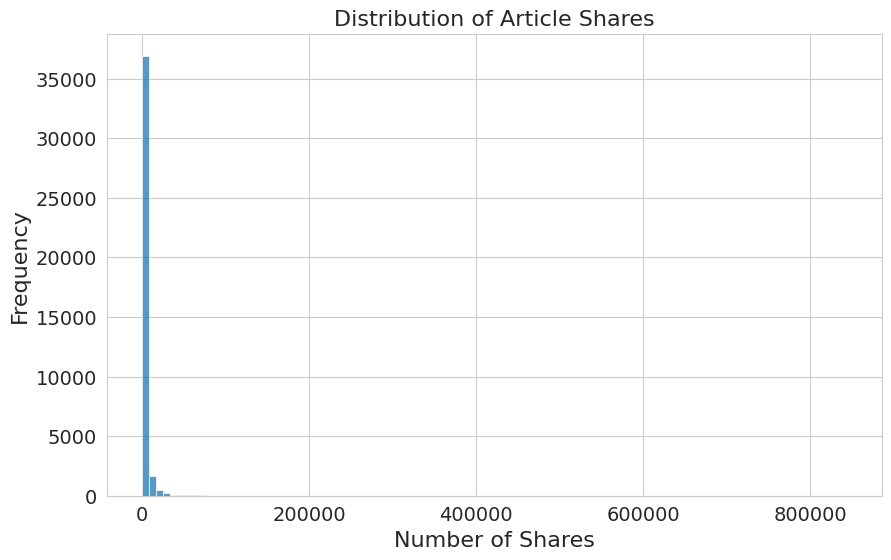

In [6]:
#Distribution of Shares
sns.histplot(df["shares"], bins=100)
plt.title("Distribution of Article Shares")
plt.xlabel("Number of Shares")
plt.ylabel("Frequency")
#plt.savefig("../figures/article_share_distribution.png")
plt.show()


A small number of shares concentrate a very high number of shares, let us give it another look.

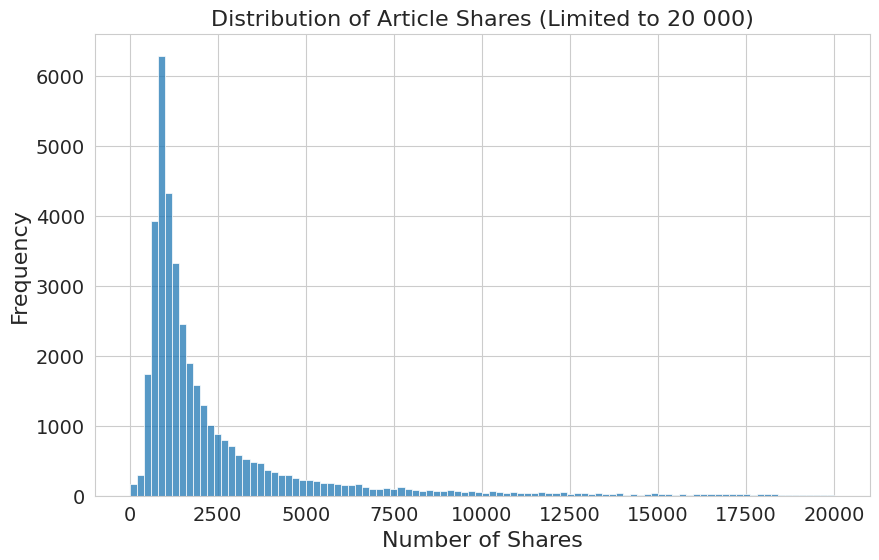

In [7]:
sns.histplot(df[df["shares"] <= 20000]["shares"], bins=100)
plt.title("Distribution of Article Shares (Limited to 20 000)")
plt.xlabel("Number of Shares")
plt.ylabel("Frequency")
plt.show()

Only 826 articles have more tha 20k shares, out of a sample of 39,000 articles

In [8]:
print(len(df[df["shares"] >= 20000]))

826


**Here we define the polarity measure we will be using**

We call it **polarization strength**, because it is the modulus sum of positive polarity and negative polarity in the article.

It can be understood as the total amount of polarity contained in the articles. It is based on the polarity intensity of positive and negative words, and on the number of these words in the article.

In [9]:
df["polarization_strength"] = (
    df["rate_positive_words"] * df["avg_positive_polarity"] +
    df["rate_negative_words"] * abs(df["avg_negative_polarity"])
)

Here, we will check the correlation between our measure of polarizaition and popularity. We observe the

In [10]:
df['log_shares'] = np.log(df['shares'])

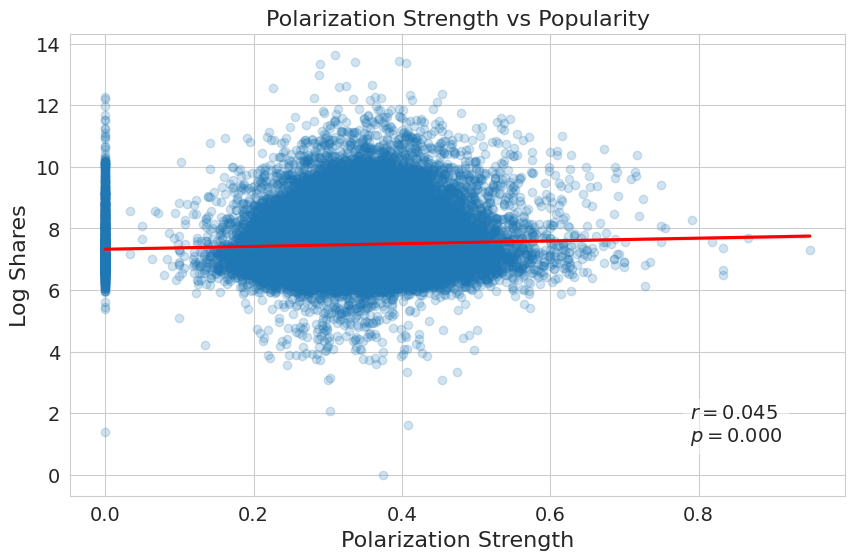

In [11]:
# calculate the conditional correlation
r, p = stats.pearsonr(df["polarization_strength"], df["log_shares"])


ax = sns.regplot(
    x="polarization_strength",
    y="log_shares",
    data=df,
    scatter_kws={"alpha": 0.2},
    order=1,
    line_kws={"color": "red"}
)


text_str = f'$r = {r:.3f}$\n$p = {p:.3f}$'
ax.text(
    0.8, 0.2, text_str,
    transform=ax.transAxes,
    fontsize=14,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.5)
)

plt.title("Polarization Strength vs Popularity")
plt.xlabel("Polarization Strength")
plt.ylabel("Log Shares")
plt.show()

# PICO Formulation

Now let us describe the **PICO formulation** of our research question.

We want to study a *Population of news articles from the Mashable website*.

The *Intervention* that we consider is a variation in the strength of polarity in the article.

Since we are not dealing with a binary treatment, we will use as *Control* the levels of polarity strength in the data.

The *Outcome* that we want to look at is the popularity of articles, that is quantified by the number of shares (to which is applied a log-transformation).

# Causal mechanism

Below we are presenting with a DAG the causal mechanism we will be studying.

Please note that this DAG is relatively simple for visual clarity purposes during the presentation.



Depending on the **subject**, and whether **this subject is trending or not at the moment**, articles published on the website are characterized differently.

They can be more or less **subjectivity** across topics. Also, **some subjects are more or less polarizing than others, whether they are popular ("hot topics") at the moment or not**. This is what we want to look into, as explained before.

Therefore people will use words that are are more or less polarizing, but polarity of the article can come through other means.

We are particularly interested in the **polarization strength**, as defined above, but other measures of polarity are proposed in Appendix, such as title polarity, or the polarity of the overall polarity of sentiment expressed in the article (in that measure positive and negative sentiments can compensate one another and attenuate polarity level, which is not the case in polarization strength). These other polarization measures have no direct causal link with the polarization strength in our understanding, becuse they are different expressions of subjectivity.

Other variables can have an effect on the popularity of the article, such as the **day of week **it is published -- we will see it is important below -- but other variables can have an effect: **length of the article, number of images, number of videos in the article, the number of other articles mentioned**.

In our DAG, only week day is mentioned for visual purpose, but all these variables previously mentioned are accounted for in the following analyses.



Nodes: ['channel', 'numPos&NegWords', 'polarization_strength', 'otherPolarity', 'subjectivity', 'dayOfWeek', 'shares']
Edges: [('channel', 'shares'), ('channel', 'otherPolarity'), ('channel', 'numPos&NegWords'), ('channel', 'subjectivity'), ('numPos&NegWords', 'polarization_strength'), ('polarization_strength', 'shares'), ('otherPolarity', 'shares'), ('subjectivity', 'numPos&NegWords'), ('subjectivity', 'shares'), ('dayOfWeek', 'shares')]
Is DAG: True


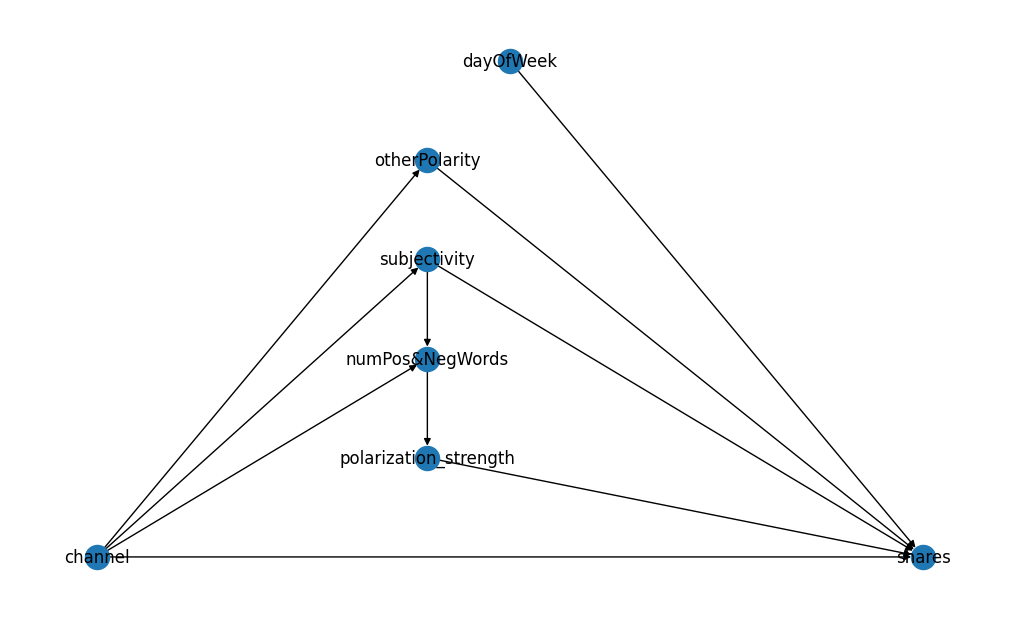

In [12]:
dag = DAG()
G = nx.DiGraph()

dag.add_nodes_from([
    "channel",
    #"#video/img",
    "numPos&NegWords",
    "polarization_strength",
    "otherPolarity",
    "subjectivity",
    "dayOfWeek",
    "shares",
])

dag.add_edges_from([
    # channel → content type cluster
    #("channel", "#video/img"),
    #("#video/img", "shares"),
    ("channel", "shares"),

    # channel → subjectivity
    ("channel", "otherPolarity"),
    ("otherPolarity", "shares"),       # was "Shares" — unified


    # channel → sentiment/polarity cluster
    ("channel", "numPos&NegWords"),
    ("numPos&NegWords", "polarization_strength"),
    ("polarization_strength", "shares"),

    ("channel", "subjectivity"),
    ("subjectivity", "numPos&NegWords"),
    ("subjectivity", "shares"),



    # publication timing → shares
    ("dayOfWeek", "shares"),          # was "#Shares" — unified
])

print("Nodes:", dag.nodes())
print("Edges:", dag.edges())
print("Is DAG:", nx.is_directed_acyclic_graph(dag))

nx.draw_planar(dag, with_labels=True)

#Data pre-processing

We convert non-categorical variables into a standard scalaer (Z-score)

In [13]:
#We remove the log shares column to avoid conflicts
df = df.drop(columns=['log_shares'], errors='ignore')

#there are -1 values for missing valus in columns we are about to log transform so we nedd to put the values back to zero
cols_to_fix = ['kw_min_min', 'kw_avg_min', 'kw_min_avg']
for col in cols_to_fix:
    if col in df.columns:
        df[col] = df[col].replace(-1, 0)

In [14]:
#We flag the binary columns for further transformations
binary_cols = [col for col in df.columns if df[col].nunique() == 2]
non_binary_cols = [col for col in df.columns if df[col].nunique() > 2]

#Here we apply the log transformation to columns with high values that are not binary
cols_to_log = [col for col in non_binary_cols if df[col].max() > 10 and col != 'shares']

df[cols_to_log] = np.log1p(df[cols_to_log])

# Cas spécial pour la cible
df['log_shares'] = np.log1p(df['shares'])
df = df.drop(columns=['shares'])



In [15]:
#Finally we rescale the non-binary columns with standardscaler
non_binary_cols = [col for col in df.columns if col not in binary_cols]

scaler = StandardScaler()
df[non_binary_cols] = scaler.fit_transform(df[non_binary_cols])

In [16]:
report2 = skrub.TableReport(df, max_plot_columns=60, max_association_columns = 60)
report2

<TableReport: use .open() to display>

# Learner Definitions

Below, we define pipelines for learners with hyperparameter selection

In [ ]:
# 1. LASSO GRID SEARCH
lasso_pipe = Pipeline([('model', Lasso(random_state=42, max_iter=10000))])

lasso_param_grid = {
    'model__alpha': np.logspace(-6, 6, 50, base=2)
}

lasso_search = GridSearchCV(
    estimator=lasso_pipe,
    param_grid=lasso_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# 2. RANDOM FOREST RANDOMIZED SEARCH
rf_pipe = Pipeline([('model', RandomForestRegressor(random_state=42, n_jobs=-1))])
rf_param_dist = {
    'model__n_estimators': randint(100, 1000),
    'model__max_depth': [None, 10, 20, 30, 50],
    'model__min_samples_leaf': randint(1, 20),
    'model__max_features': ['sqrt', 'log2', 0.3, 0.5]
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipe,
    param_distributions=rf_param_dist,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

# 3. XGBOOST RANDOMIZED SEARCH
xgb_pipe = Pipeline([('model', XGBRegressor(random_state=42, n_jobs=-1, objective='reg:squarederror'))])
xgb_param_dist = {
    'model__n_estimators': randint(500, 1500),
    'model__learning_rate': uniform(0.01, 0.2),
    'model__max_depth': randint(3, 10),
    'model__subsample': uniform(0.6, 0.4),
    'model__colsample_bytree': uniform(0.6, 0.4)
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_pipe,
    param_distributions=xgb_param_dist,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)


In [ ]:
# Définir une validation croisée 5-fold avec mélange des données
cv = KFold(n_splits=5, shuffle=True, random_state=42)

now when refering to learners we can use cross validation of hyperparameters as below

In [ ]:
# This will run the search (inner CV) inside each fold of cv_outer (outer CV)
    results = cross_validate(
        search_object,
        X_train,
        y_train,
        cv=cv_outer,
        scoring='r2',
        return_estimator=True,
        return_train_score=True,
        n_jobs=-1 # Using parallel processing for the outer loop as well
    )

    all_models_results[name] = results

# Exploratory Data Analysis

In this section we conduct exploratory data analysis with the work of raphael using specifically the measure that we will have chosen, and the control features that we are looking for

Check the correlations of variables in the DAG with shares

/tmp/ipykernel_14126/205740454.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=10)


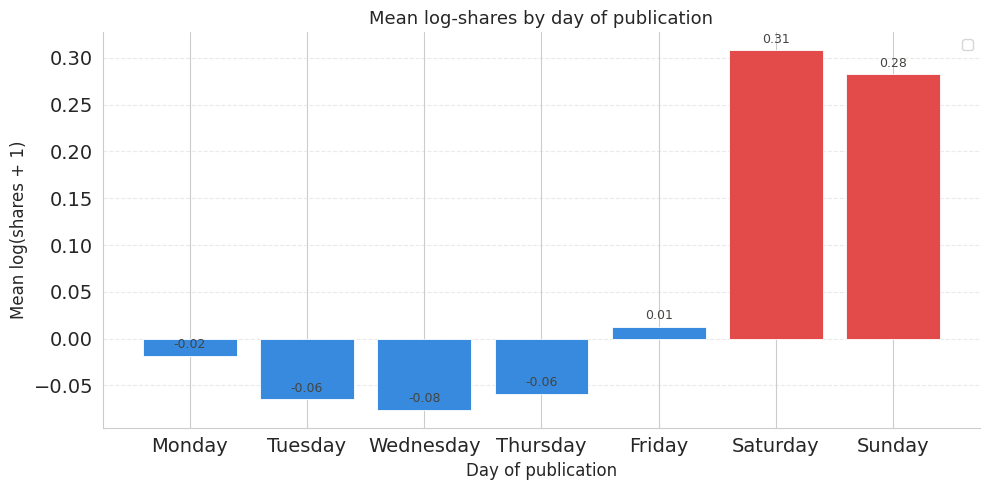

In [ ]:
# day of week
day_cols = [
    "weekday_is_monday", "weekday_is_tuesday", "weekday_is_wednesday",
    "weekday_is_thursday", "weekday_is_friday",
    "weekday_is_saturday", "weekday_is_sunday",
]

labels = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

means = [df.loc[df[col] == 1, "log_shares"].mean() for col in day_cols]

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 5))

colors = ["#378ADD" if d not in ("Saturday", "Sunday") else "#E24B4A" for d in labels]

ax.bar(labels, means, color=colors, edgecolor="white", linewidth=0.6)

ax.set_ylabel("Mean log(shares + 1)", fontsize=12)
ax.set_xlabel("Day of publication", fontsize=12)
ax.set_title("Mean log-shares by day of publication", fontsize=13, fontweight="normal")
ax.legend(fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)

# Annotate mean values on top of each bar
for i, m in enumerate(means):
    ax.text(i, m + 0.005, f"{m:.2f}", ha="center", va="bottom", fontsize=9, color="#444441")

plt.tight_layout()
#plt.savefig("dayofweek_barplot_simple.png", dpi=150, bbox_inches="tight")
plt.show()

We can see from the following that global subjectivity seems more correlated.

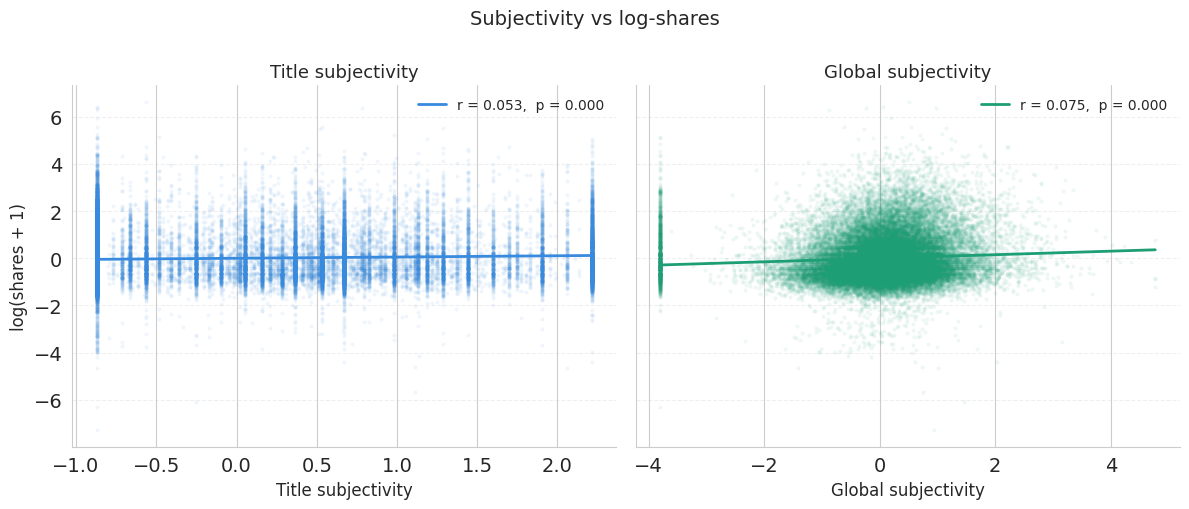

In [ ]:
vars_ = ["title_subjectivity", "global_subjectivity"]
labels = ["Title subjectivity", "Global subjectivity"]
colors = ["#378ADD", "#1D9E75"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, col, label, color in zip(axes, vars_, labels, colors):
    x = df[col].dropna()
    y = df.loc[x.index, "log_shares"]

    # Scatter
    ax.scatter(x, y, alpha=0.08, s=8, color=color, linewidths=0)

    # OLS regression line
    slope, intercept, r, p, _ = stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 200)
    ax.plot(x_line, intercept + slope * x_line, color=color,
            linewidth=2, label=f"r = {r:.3f},  p = {p:.3f}")

    ax.set_xlabel(label, fontsize=12)
    ax.set_title(label, fontsize=13, fontweight="normal")
    ax.legend(fontsize=10, frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
    ax.yaxis.grid(True, linestyle="--", alpha=0.3)
    ax.set_axisbelow(True)

axes[0].set_ylabel("log(shares + 1)", fontsize=12)
fig.suptitle("Subjectivity vs log-shares", fontsize=14, fontweight="normal", y=1.01)

plt.tight_layout()
#plt.savefig("subjectivity_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

### Permutation Analysis

Here, we use permutation analysis to show which variables are correlated with Number of shares besides the aforementioned variables on subjectivity and polarity. This serves as a basis for selecting the set of covariates in the following analysis, and complements the DAG analysis to see any sings of relationships between variables and number of shares

We use permutation analysis using Random Forests, as it was the model with the highest accuracy for predicting popularity in the original article which analyzed the dataset. It is important to note that permutation analysis tells us which variables are imortant for the given model (RF here), but not for other models. Thus, we just take this into account but not as an absolute criteria.

We can observe that in addition to the variables in the DAG, keyword and LDA related variables may be important.


In [ ]:
baseline_features = words_cols + links_cols + digital_media_cols + keywords_cols + [ "LDA_00", "LDA_01", "LDA_02", "LDA_03", "LDA_04"]

 # ── 3. Train/test split ──────────────────────────────────────────────
data = df[baseline_features + ["log_shares"]].dropna()

split_idx = int(len(data) * 0.8)
train = data.iloc[:split_idx]
test  = data.iloc[split_idx:]


In [ ]:
# ── 4. Train random forest ────────────────────────────────────────────────────
model = RandomForestRegressor(n_estimators=300, min_samples_leaf=3,
                              random_state=42, n_jobs=-1)
model.fit(train[baseline_features], train["log_shares"])

rmse = np.sqrt(mean_squared_error(test["log_shares"],
                                  model.predict(test[baseline_features])))
print(f"Baseline RMSE: {rmse:.4f}")


Baseline RMSE: 0.9054


In [ ]:
# ── 5. Permutation importance ─────────────────────────────────────────────────
perm = permutation_importance(
    model,
    test[baseline_features],
    test["log_shares"],
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
)

imp = (pd.DataFrame({
    "feature":    baseline_features,
    "importance": perm.importances_mean,
    "std":        perm.importances_std,
}).sort_values("importance", ascending=False))

print("\nPermutation importance:")
print(imp.to_string(index=False))


Permutation importance:
                   feature  importance      std
                kw_avg_avg    0.110796 0.004844
self_reference_avg_sharess    0.014684 0.001723
                kw_max_avg    0.014123 0.001401
                 num_hrefs    0.010669 0.001709
                    LDA_04    0.009093 0.001928
           n_unique_tokens    0.007929 0.001432
 self_reference_min_shares    0.006696 0.002040
      average_token_length    0.004954 0.001038
                    LDA_00    0.004537 0.002534
                  num_imgs    0.004423 0.000785
          n_tokens_content    0.004333 0.000986
                    LDA_01    0.004048 0.001456
                kw_avg_max    0.003529 0.000768
                kw_min_max    0.003523 0.001010
  n_non_stop_unique_tokens    0.003500 0.001084
                kw_min_avg    0.003019 0.000546
                num_videos    0.002792 0.000301
                kw_avg_min    0.002343 0.000697
                    LDA_02    0.001622 0.001190
               

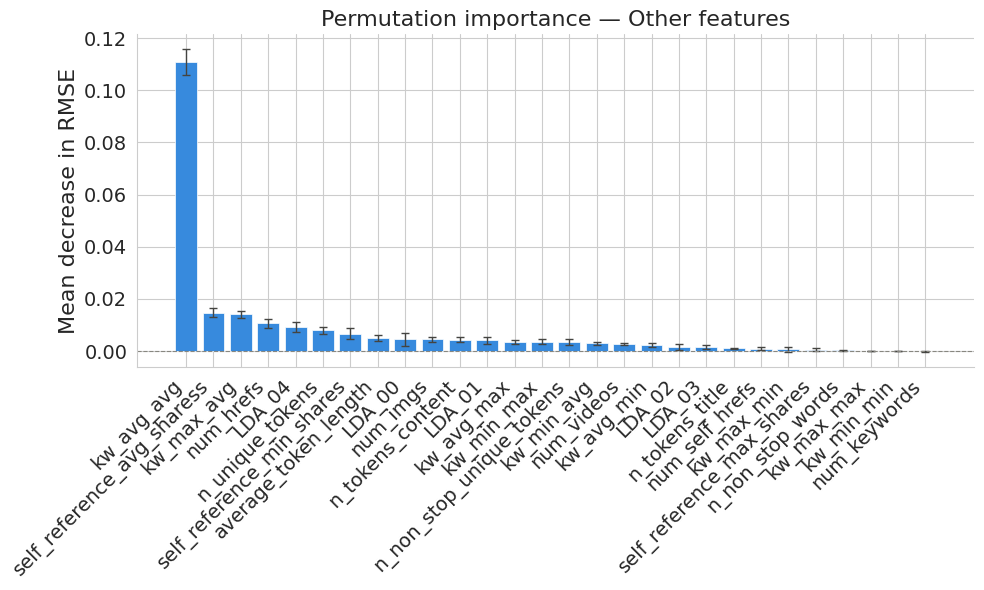

In [ ]:
imp_sorted = imp.sort_values("importance", ascending=False)

fig, ax = plt.subplots()

ax.bar(imp_sorted["feature"], imp_sorted["importance"],
       yerr=imp_sorted["std"], capsize=3,
       color="#378ADD", edgecolor="white", linewidth=0.5,
       error_kw=dict(elinewidth=1, ecolor="#444441", capthick=1))

ax.axhline(0, color="#888780", linewidth=0.8, linestyle="--")
ax.set_ylabel("Mean decrease in RMSE")
ax.set_title("Permutation importance — Other features")
ax.spines[["top", "right"]].set_visible(False)
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

# Statistical Estimator/Model Selection

In this section we include estimations with the following methods:

- econometric analysis
- casual inference using dml


### We explain our econometric analysis  

- Naive regression without additional control or FE
  - Here, we observe that there is a positive correlation between polarization and number of shares, but the analysis is naive and warrants caution.
- Regression with controls and fixed effects
  - Controlling for image, videos, and subjectivity, the correlation between polarization and number of shares is now negative. These are the variables we deemed important in determining article popularity in the DAG. We still cannot draw conclusion on the causality
  - Adding a more stringent set of controls, inspired by the permutation analysis such as number of links, n_tokens etc, make the polarization variable insifnificant. It seems addition of n_tokens_content (number of words in the contnet) reduces the significance of the polorization variable

- Regression with controls and time and channel(topic) fixed effects
   - The negative correlation between poalrization and polarity is still robuts to the inclusion of time and channel FEs. However, the setup may not guarantee that the correlation is indeed causal, as we are not sure the effect is linear or conditional confoundedness holds in this case.


In [17]:
X1 = sm.add_constant(df[["polarization_strength"]])
y = df["log_shares"]

model_naive = sm.OLS(y, X1).fit()
print(model_naive.summary())


                            OLS Regression Results                            
Dep. Variable:             log_shares   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     78.98
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           6.53e-19
Time:                        05:42:15   Log-Likelihood:                -56213.
No. Observations:               39644   AIC:                         1.124e+05
Df Residuals:                   39642   BIC:                         1.124e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                  2.461e-

In [18]:
controls = [
    "global_subjectivity",
    "n_tokens_content",
    "num_imgs",
    "num_videos",
    "is_weekend"
]

X2 = sm.add_constant(df[["polarization_strength"] + controls])

model_control = sm.OLS(y, X2).fit()

print(model_control.summary())

                            OLS Regression Results                            
Dep. Variable:             log_shares   R-squared:                       0.040
Model:                            OLS   Adj. R-squared:                  0.040
Method:                 Least Squares   F-statistic:                     276.3
Date:                Tue, 24 Mar 2026   Prob (F-statistic):               0.00
Time:                        05:42:15   Log-Likelihood:                -55440.
No. Observations:               39644   AIC:                         1.109e+05
Df Residuals:                   39637   BIC:                         1.110e+05
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -0.04

In [19]:
topics = ["LDA_00", "LDA_01", "LDA_02", "LDA_03", "LDA_04"] + ['kw_avg_avg', 'self_reference_avg_sharess', 'num_hrefs']

X3 = sm.add_constant(df[["polarization_strength"] + controls + topics])

model_strong_control = sm.OLS(y, X3).fit()

print(model_strong_control.summary())

                            OLS Regression Results                            
Dep. Variable:             log_shares   R-squared:                       0.087
Model:                            OLS   Adj. R-squared:                  0.086
Method:                 Least Squares   F-statistic:                     268.4
Date:                Tue, 24 Mar 2026   Prob (F-statistic):               0.00
Time:                        05:42:15   Log-Likelihood:                -54457.
No. Observations:               39644   AIC:                         1.089e+05
Df Residuals:                   39629   BIC:                         1.091e+05
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

In [20]:
# Create entity (group) variable
channels = [
    "data_channel_is_lifestyle",
    "data_channel_is_entertainment",
    "data_channel_is_bus",
    "data_channel_is_socmed",
    "data_channel_is_tech",
    #"data_channel_is_world"
]

df["entity_id"] = df[channels].idxmax(axis=1)

# access the date of the data
df['date_str'] = online_news_popularity.data.original['url'].str.extract(r'(\d{4}/\d{2}/\d{2})')
df['publish_date'] = pd.to_datetime(df['date_str'])

# Set panel structure
df_panel = df.set_index(["entity_id", "publish_date"]).copy()

X = df_panel[["polarization_strength"] + controls + topics]

y = df_panel["log_shares"]

# Add constant
X = sm.add_constant(X)

# Run PanelOLS (entity fixed effects only)
model_panel = PanelOLS(
    y,
    X,
    entity_effects=True
)

# Fit with clustered standard errors
results_panel = model_panel.fit(cov_type="clustered", cluster_entity=True)

print(results_panel)

                          PanelOLS Estimation Summary                           
Dep. Variable:             log_shares   R-squared:                        0.0867
Estimator:                   PanelOLS   R-squared (Between):             -0.1668
No. Observations:               39644   R-squared (Within):               0.0867
Date:                Tue, Mar 24 2026   R-squared (Overall):              0.0761
Time:                        05:42:16   Log-likelihood                -5.415e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      268.85
Entities:                           5   P-value                           0.0000
Avg Obs:                       7928.8   Distribution:                F(14,39625)
Min Obs:                       2323.0                                           
Max Obs:                    1.666e+04   F-statistic (robust):         -2.737e+15
                            

In [24]:
# report the result in latex
table = Stargazer([model_naive, model_control, model_strong_control, results_panel])

table.title("Effect of Polarization Strength on Log-Shares")
table.custom_columns(["Naive", "Controls", "Strong Controls", "Strong + FEs"], [1, 1, 1, 1])
table.show_degrees_of_freedom(False)
table.significant_digits(3)

table.covariate_order([
    "polarization_strength",
    "global_subjectivity",
    "n_tokens_content",
    "num_imgs",
    "kw_avg_avg",
    "num_hrefs"

])

table.rename_covariates({
    "polarization_strength": "Polarization Strength",
    "global_subjectivity":   "Global Subjectivity",
    "n_tokens_content":      "Content Length",
    "num_imgs":              "Num. Images",
    "kw_avg_avg": "Avg Share Keyword",
    "num_hrefs": "Num. Links"
})

# Add FE indicator rows — one per FE type, True/False per model
table.add_line("Strong Controls",  ["No", "No", "Yes", "Yes"])
table.add_line("Channel FE",  ["No", "No", "No", "Yes"])
table.add_line("Day-of-Week FE", ["No", "No",  "No", "Yes"])

print(table.render_latex())

\begin{table}[!htbp] \centering
  \caption{Effect of Polarization Strength on Log-Shares}
\begin{tabular}{@{\extracolsep{5pt}}lcccc}
\\[-1.8ex]\hline
\hline \\[-1.8ex]
& \multicolumn{4}{c}{\textit{Dependent variable: log_shares}} \
\cr \cline{2-5}
\\[-1.8ex] & \multicolumn{1}{c}{Naive} & \multicolumn{1}{c}{Controls} & \multicolumn{1}{c}{Strong Controls} & \multicolumn{1}{c}{Strong + FEs}  \\
\\[-1.8ex] & (1) & (2) & (3) & (4) \\
\hline \\[-1.8ex]
 Polarization Strength & 0.045$^{***}$ & -0.008$^{}$ & -0.027$^{***}$ & -0.024$^{**}$ \\
& (0.005) & (0.007) & (0.007) & (0.012) \\
 Global Subjectivity & & 0.119$^{***}$ & 0.073$^{***}$ & 0.054$^{***}$ \\
& & (0.007) & (0.007) & (0.010) \\
 Content Length & & -0.117$^{***}$ & -0.115$^{***}$ & -0.083$^{**}$ \\
& & (0.006) & (0.008) & (0.034) \\
 Num. Images & & 0.120$^{***}$ & 0.073$^{***}$ & 0.068$^{***}$ \\
& & (0.005) & (0.006) & (0.012) \\
 Avg Share Keyword & & & 0.125$^{***}$ & 0.115$^{***}$ \\
& & & (0.005) & (0.020) \\
 Num. Links & & 

### We explain our causal inference using DML

We consider a set of candidate learners for estimating the nuisance functions E[Y∣X] and E[T∣X], including Lasso, Random Forest, Gradient Boosting, and OLS. This allows the model to flexibly capture both linear and nonlinear relationships. The best-performing model is selected based on predictive performance (RMSE).The nuisance models achieve reasonable predictive performance.

In [ ]:
learners_y = {
    "Lasso": LassoCV(cv=5),
    "RF": RandomForestRegressor(
        n_estimators=200,
        max_depth=5,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ),
    "Boost": HistGradientBoostingRegressor(
        max_depth=5,
        learning_rate=0.05,
        random_state=42
    ),
    "OLS": LinearRegression()
}

learners_t = {
    "Lasso": LassoCV(cv=5),
    "RF": RandomForestRegressor(
        n_estimators=200,
        max_depth=5,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ),
    "Boost": HistGradientBoostingRegressor(
        max_depth=5,
        learning_rate=0.05,
        random_state=42
    ),
    "OLS": LinearRegression()
}

In [ ]:
def run_dml_pipeline(df, outcome_col, treat_col, X_cols, learners_y, learners_t,
                     n_splits=5, random_state=42, n_bootstrap=500):
    """
    Run a DML pipeline:
    1. prepare data
    2. score nuisance learners by CV RMSE
    3. choose best learner for E[Y|X] and E[T|X]
    4. fit final DML model
    5. return summary + fitted model
    """

    # ---------------------------
    # STEP 1: Prepare data
    # ---------------------------
    dml_df = df[[outcome_col, treat_col] + X_cols].dropna().astype(float)

    Y = dml_df[outcome_col].to_numpy()
    T = dml_df[treat_col].to_numpy()
    X = dml_df[X_cols].to_numpy()

    # ---------------------------
    # STEP 2: CV setup
    # ---------------------------
    cv = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    def rmse_cv(model, X, y):
        preds = cross_val_predict(clone(model), X, y, cv=cv)
        return np.sqrt(mean_squared_error(y, preds))

    # ---------------------------
    # STEP 3: Score Y learners
    # ---------------------------
    rmse_y_df = pd.DataFrame([
        {
            "learner_y": name,
            "rmse_y": rmse_cv(model, X, Y)
        }
        for name, model in learners_y.items()
    ]).sort_values("rmse_y").reset_index(drop=True)

    # ---------------------------
    # STEP 4: Score T learners
    # ---------------------------
    rmse_t_df = pd.DataFrame([
        {
            "learner_t": name,
            "rmse_t": rmse_cv(model, X, T)
        }
        for name, model in learners_t.items()
    ]).sort_values("rmse_t").reset_index(drop=True)

    # ---------------------------
    # STEP 5: Select best learners
    # ---------------------------
    best_y_name = rmse_y_df.loc[0, "learner_y"]
    best_t_name = rmse_t_df.loc[0, "learner_t"]

    # ---------------------------
    # STEP 6: Final DML estimation
    # ---------------------------
    best_model = DML(
        model_y=clone(learners_y[best_y_name]),
        model_t=clone(learners_t[best_t_name]),
        model_final=LinearRegression(),
        discrete_treatment=False,
        random_state=random_state
    )

    best_model.fit(
        Y, T, X=X,
        inference=BootstrapInference(n_bootstrap_samples=n_bootstrap, n_jobs=-1)
    )

    ate = best_model.ate(X)
    ci_low, ci_high = best_model.ate_interval(X)

    # ---------------------------
    # STEP 7: Final summary
    # ---------------------------
    final_summary = pd.DataFrame([{
        "outcome": outcome_col,
        "treatment": treat_col,
        "best_y": best_y_name,
        "best_t": best_t_name,
        "ate": float(ate),
        "ci_low": float(ci_low),
        "ci_high": float(ci_high),
        "n_obs": len(dml_df)
    }])

    return {
        "summary": final_summary,
        "rmse_y_df": rmse_y_df,
        "rmse_t_df": rmse_t_df,
        "model": best_model,
        "data_used": dml_df
    }


In [ ]:
res_dml = run_dml_pipeline(
    df=df,
    outcome_col="log_shares",
    treat_col="polarization_strength",
    X_cols=controls + topics ,
    learners_y=learners_y,
    learners_t=learners_t
)
print(res_dml["summary"]["ate"].iloc[0], (res_dml["summary"]["ci_low"].iloc[0], res_dml["summary"]["ci_high"].iloc[0]))

/usr/local/lib/python3.12/dist-packages/econml/dml/dml.py:192: UserWarning: The final model has a nonzero intercept for at least one outcome; it will be subtracted, but consider fitting a model without an intercept if possible.
  warn("The final model has a nonzero intercept for at least one outcome; "
/usr/local/lib/python3.12/dist-packages/econml/dml/dml.py:192: UserWarning: The final model has a nonzero intercept for at least one outcome; it will be subtracted, but consider fitting a model without an intercept if possible.
  warn("The final model has a nonzero intercept for at least one outcome; "
/usr/local/lib/python3.12/dist-packages/econml/dml/dml.py:192: UserWarning: The final model has a nonzero intercept for at least one outcome; it will be subtracted, but consider fitting a model without an intercept if possible.
  warn("The final model has a nonzero intercept for at least one outcome; "
/usr/local/lib/python3.12/dist-packages/econml/dml/dml.py:192: UserWarning: The final mo

-0.07014067068728778 (np.float64(-0.634748172091377), np.float64(0.4944668307168013))


In [ ]:
def plot_dml_results(res_dml, figsize=(16, 5)):
    """
    Plot DML results including:
    1. ATE with confidence interval
    2. RMSE for E[Y|X]
    3. RMSE for E[T|X]

    Parameters
    ----------
    res_dml : dict
        Dictionary containing:
        - summary
        - rmse_y_df
        - rmse_t_df
    figsize : tuple
        Figure size
    """

    # --- Extract data ---
    summary_df = res_dml["summary"].copy()
    rmse_y_df = res_dml["rmse_y_df"].copy().sort_values("rmse_y", ascending=True)
    rmse_t_df = res_dml["rmse_t_df"].copy().sort_values("rmse_t", ascending=True)

    ate = summary_df.loc[0, "ate"]
    ci_low = summary_df.loc[0, "ci_low"]
    ci_high = summary_df.loc[0, "ci_high"]
    treatment = summary_df.loc[0, "treatment"]
    outcome = summary_df.loc[0, "outcome"]

    err_low = ate - ci_low
    err_high = ci_high - ate

    # --- Create figure ---
    fig, axes = plt.subplots(1, 3, figsize=figsize)

    # --- ATE plot ---
    axes[0].errorbar(
        x=[treatment],
        y=[ate],
        yerr=[[err_low], [err_high]],
        fmt='o',
        capsize=6
    )
    axes[0].axhline(0, linestyle='--')
    axes[0].set_title("ATE with 95% CI")
    axes[0].set_ylabel("Effect")
    axes[0].set_xlabel("Treatment")

    # --- RMSE Y plot ---
    axes[1].barh(rmse_y_df["learner_y"], rmse_y_df["rmse_y"])
    axes[1].set_title("RMSE for E[Y|X]")
    axes[1].set_xlabel("RMSE")
    axes[1].set_ylabel("Learner")

    # --- RMSE T plot ---
    axes[2].barh(rmse_t_df["learner_t"], rmse_t_df["rmse_t"])
    axes[2].set_title("RMSE for E[T|X]")
    axes[2].set_xlabel("RMSE")
    axes[2].set_ylabel("Learner")

    plt.suptitle(f"DML Results: {treatment} → {outcome}", y=1.02)
    plt.tight_layout()
    plt.show()

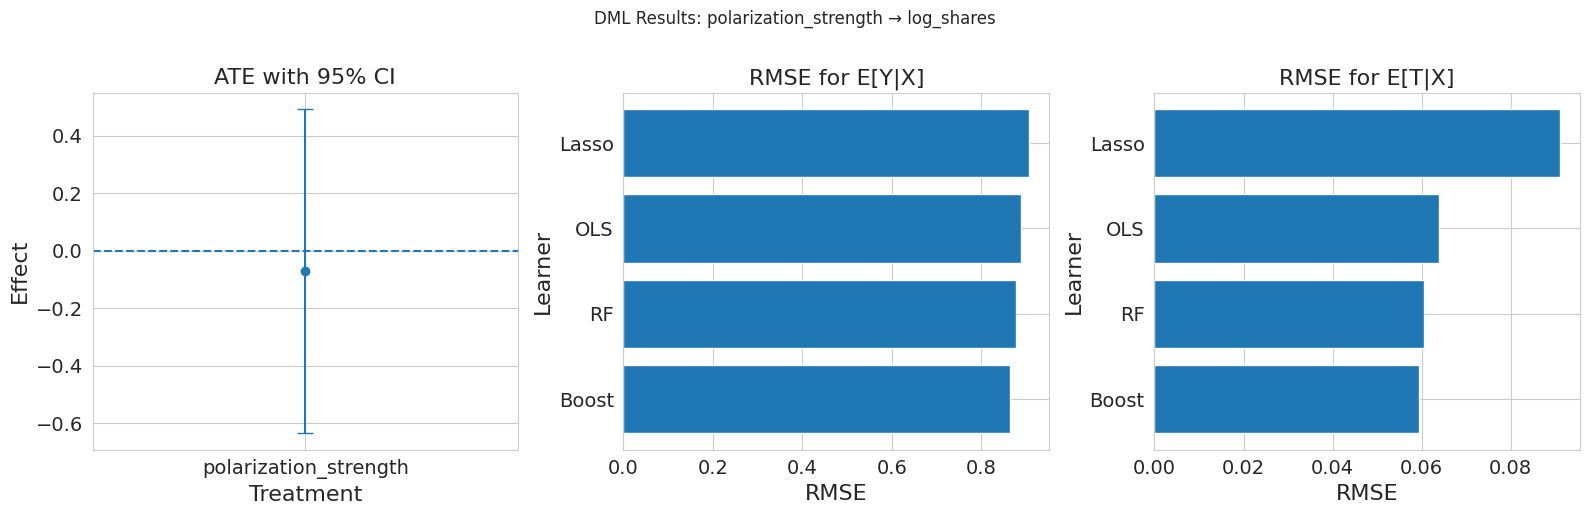

In [ ]:
    plot_dml_results(res_dml)

For the outcome model𝐸[𝑌∣𝑋], gradient boosting achieves the lowest RMSE (0.929), outperforming linear models such as OLS and Lasso. Similarly, for the treatment model E[T∣X], gradient boosting also performs best (RMSE = 0.642). These results suggest that the relationships between covariates and both outcome and treatment are nonlinear, and that the DML procedure is based on sufficiently flexible models.

# Heterogeneous treatment effect: Subjectivity


This section extends the analysis by examining whether the impact of polarization
on article popularity varies depending on the level of subjectivity.
While previous models estimate an average effect of polarization, this approach allows us to uncover heterogeneous treatment effects (HTE), i.e., how the effect differs across types of articles.
Specifically, we have:
 - Treatment: High polarization (binary)
 - Outcome: log(shares)
 - Heterogeneity dimension: Article subjectivity

We implement two approaches:
 1. T-learner (separate models for treated and control groups)
 2. S-learner (single model with treatment as a feature)

Goal:

Estimate τ(x) = effect of polarization on popularity for each article and analyze how this effect varies with subjectivity

In [ ]:
# Define treatment: high polarization
df["high_polarization"] = (
    df["polarization_strength"] > df["polarization_strength"].median()
).astype(int)

# Define heterogeneity dimension: subjectivity
df["high_subjectivity"] = (
    df["global_subjectivity"] > df["global_subjectivity"].median()
).astype(int)

In [ ]:
# T - Learner:
# Train two separate models:
# One for treated (high polarization)
# One for control (low polarization)
from sklearn.ensemble import RandomForestRegressor

# Features (exclude treatment!)
features = [
    "n_tokens_content",
    "num_imgs",
    "num_videos",
    "is_weekend",
    "LDA_00", "LDA_01", "LDA_02", "LDA_03", "LDA_04"
]

X = df[features]
y = df["log_shares"]
T = df["high_polarization"]

# Split groups
X_treated = X[T == 1]
y_treated = y[T == 1]

X_control = X[T == 0]
y_control = y[T == 0]

# Train two models
model_t = RandomForestRegressor(n_estimators=100)
model_c = RandomForestRegressor(n_estimators=100)

model_t.fit(X_treated, y_treated)
model_c.fit(X_control, y_control)

# Estimate treatment effect
tau_t = model_t.predict(X) - model_c.predict(X)

df["tau_tlearner"] = tau_t

In [ ]:
#S-LEARNER: Train one model including treatment as a feature
# Add treatment to features
X_s = X.copy()
X_s["high_polarization"] = T

model_s = RandomForestRegressor(n_estimators=100)
model_s.fit(X_s, y)

# Counterfactual predictions
X1 = X.copy()
X1["high_polarization"] = 1

X0 = X.copy()
X0["high_polarization"] = 0

tau_s = model_s.predict(X1) - model_s.predict(X0)

df["tau_slearner"] = tau_s

In [ ]:
#Analyze heterogeneity
df.groupby("high_subjectivity")[["tau_tlearner", "tau_slearner"]].mean()

,tau_tlearner,tau_slearner
high_subjectivity,,
0,0.013726,0.012749
1,0.041470,0.015150


In [ ]:
#Compare S vs T learner
df[["tau_tlearner", "tau_slearner"]].describe()

,tau_tlearner,tau_slearner
count,39644.000000,39644.000000
mean,0.027598,0.013949
std,0.633178,0.122438
min,-4.923585,-0.839065
25%,-0.351086,-0.056612
50%,0.014426,0.007162
75%,0.389493,0.074563
max,3.854891,1.054868


<Axes: xlabel='high_subjectivity', ylabel='tau_tlearner'>

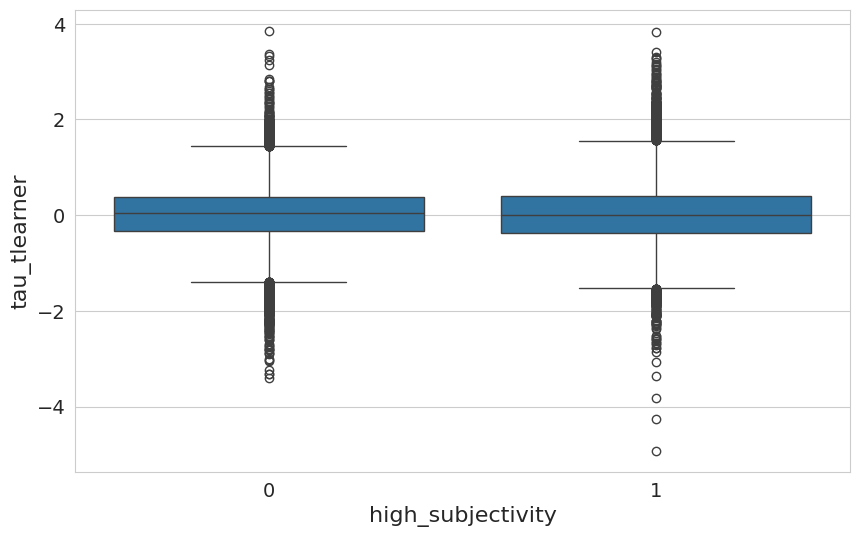

In [ ]:
import seaborn as sns

sns.boxplot(
    x="high_subjectivity",
    y="tau_tlearner",
    data=df
)

The estimated treatment effects show that polarization has a slightly negative effect on average. However, the distribution of effects is wide, indicating strong
heterogeneity across articles.
When grouped by subjectivity:
- The negative effect of polarization is stronger for low-subjectivity articles
- The effect is weaker for highly subjective articles

This suggests that emotional intensity is less effective in factual content,but more compatible with opinion-driven articles.
Additionally, the T-learner captures stronger heterogeneity, while the S-learner produces smoother and more stable estimates.

# Extension: Clickbait study

This section examines whether clickbait-style headlines are effective in increasing article popularity. Rather than focusing solely on the average effect, we investigate
whether the effectiveness of clickbait varies across articles.
In particular, we ask:
- Does clickbait increase engagement on average?
- Does its impact vary across articles?
- What factors (e.g., subjectivity, topic, polarization) explain this variation?
#
This approach allows us to move beyond average effects and understand when clickbait is actually effective.

**Clickbait** is commonly understood as a strategy where headlines are designed to attract attention by exaggerating or distorting the underlying content. A key characteristic of such headlines is the creation of a gap between the expectation set by the title and the actual substance of the article. In particular, clickbait often relies on emotionally charged or sensational phrasing that does not accurately reflect the tone of the content itself.

Motivated by this idea, we focus on the extent of mismatch between the sentiment expressed in the headline and that of the article. A larger divergence suggests that the headline is amplifying or altering the emotional signal relative to the content, which is consistent with the notion of clickbait as a tool for capturing attention through exaggeration or misalignment. This provides a data-driven and scalable way to quantify clickbait intensity without relying on manual labeling.

It is important to note that this proxy captures one specific dimension of clickbait—namely sentiment exaggeration—and does not account for other forms such as curiosity gaps or structural headline patterns.

In [ ]:
# Clickbait = mismatch between title and content sentiment
df["clickbait"] = abs(
    df["title_sentiment_polarity"] - df["global_sentiment_polarity"]
)

# Binary treatment
df["clickbait_high"] = (
    df["clickbait"] > df["clickbait"].median()
).astype(int)

In [ ]:
#Setup Data
features = [
    "polarization_strength",
    "global_subjectivity",
    "n_tokens_content",
    "num_imgs",
    "num_videos",
    "is_weekend",
    "LDA_00", "LDA_01", "LDA_02", "LDA_03", "LDA_04"
]

X = df[features]
y = df["log_shares"]
T = df["clickbait_high"]

In [ ]:
#T-Learner
# Split treated / control
X_treated = X[T == 1]
y_treated = y[T == 1]

X_control = X[T == 0]
y_control = y[T == 0]

# Train models
model_t = RandomForestRegressor(n_estimators=100)
model_c = RandomForestRegressor(n_estimators=100)

model_t.fit(X_treated, y_treated)
model_c.fit(X_control, y_control)

# Estimate treatment effect
df["tau_clickbait_t"] = model_t.predict(X) - model_c.predict(X)

In [ ]:
#S- learner
# Add treatment as feature
X_s = X.copy()
X_s["clickbait_high"] = T

model_s = RandomForestRegressor(n_estimators=100)
model_s.fit(X_s, y)

# Counterfactuals
X1 = X.copy()
X1["clickbait_high"] = 1

X0 = X.copy()
X0["clickbait_high"] = 0

df["tau_clickbait_s"] = model_s.predict(X1) - model_s.predict(X0)

In [ ]:
df[["tau_clickbait_t", "tau_clickbait_s"]].describe()

,tau_clickbait_t,tau_clickbait_s
count,39644.000000,39644.000000
mean,-0.006528,-0.006806
std,0.654976,0.098504
min,-4.711460,-1.738619
25%,-0.396799,-0.055693
50%,-0.009489,-0.002143
75%,0.376174,0.047380
max,4.130998,0.627348


The average effect of clickbait on article popularity is close to zero. However, the wide distribution of estimated treatment effects indicates substantial heterogeneity. Clickbait significantly increases engagement for some articles while reducing it for others, suggesting that its effectiveness is highly context-dependent.

The T-learner captures substantial variation in treatment effects, while the S-learner provides more stable estimates. The consistency between the two approaches reinforces the conclusion that the average effect of clickbait is close to zero.

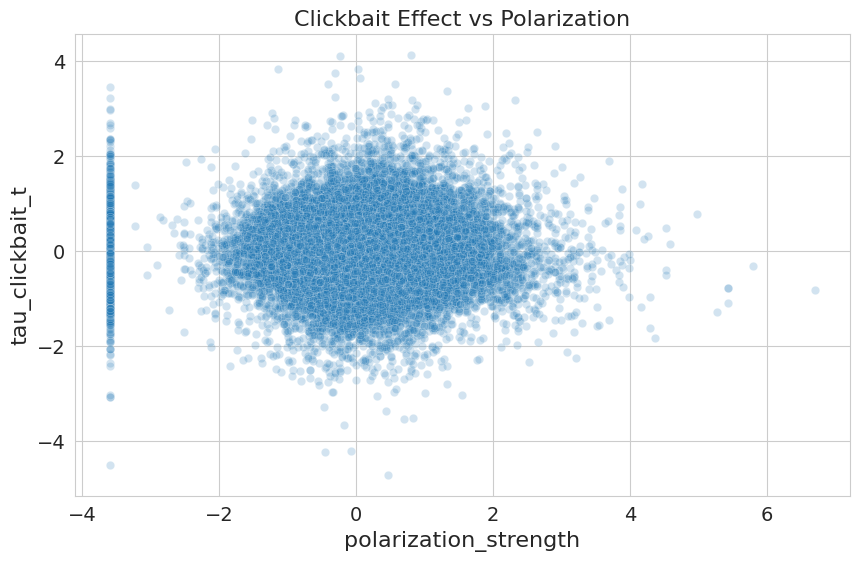

In [ ]:
# Relationship between polarization and clickbait effect
sns.scatterplot(
    x="polarization_strength",
    y="tau_clickbait_t",
    data=df,
    alpha=0.2
)

plt.title("Clickbait Effect vs Polarization")
plt.show()

/tmp/ipykernel_193/2780757965.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("pol_bin")["tau_clickbait_t"].mean().plot(kind="bar")


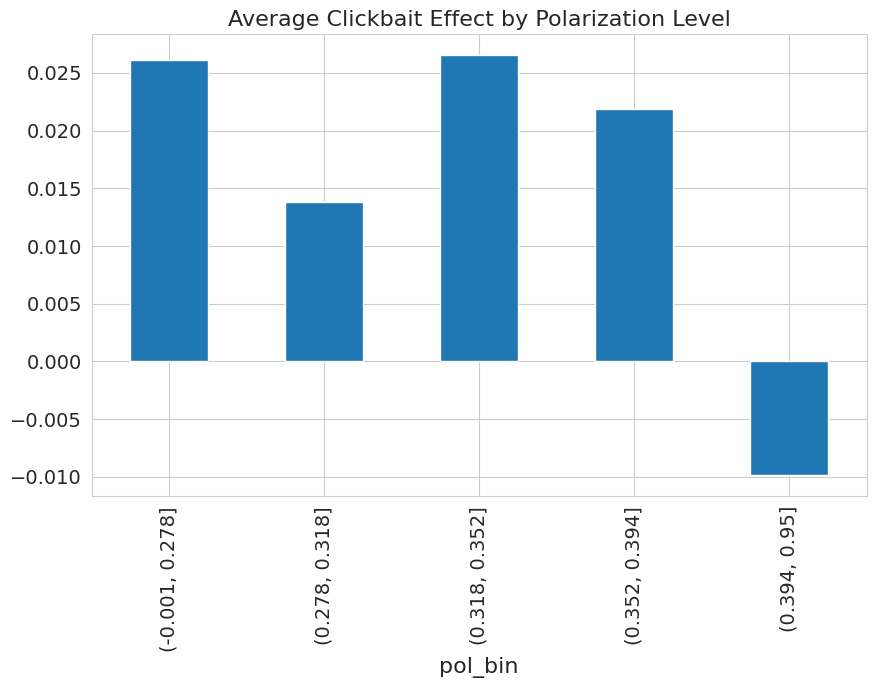

In [ ]:
# Bin polarization
df["pol_bin"] = pd.qcut(df["polarization_strength"], 5)

df.groupby("pol_bin")["tau_clickbait_t"].mean().plot(kind="bar")
plt.title("Average Clickbait Effect by Polarization Level")
plt.show()


The relationship between polarization and the effectiveness of clickbait is not monotonic. While moderate levels of polarization are associated with slightly positive effects, highly polarized articles exhibit a strongly negative response to clickbait.
At high levels of polarization, clickbait appears to backfire, potentially due to audience fatigue or reduced credibility of overly exaggerated content.
 This suggests that emotional intensity alone does not explain when clickbait is effective.

While the scatter plot shows substantial noise and no clear linear pattern, this is due to high variance in individual-level treatment effects. Aggregated (binned) results reveal a clearer underlying trend, indicating that the relationship exists but is relatively weak compared to overall variability.

Clickbait does not have a uniform effect on article popularity. While its average impact is close to zero, there is significant heterogeneity across articles, with some benefiting greatly and others being negatively affected. Furthermore, the effectiveness of clickbait does not appear to be systematically driven by polarization, and in highly polarized content, clickbait may even backfire. These findings suggest that the success of clickbait depends on contextual factors beyond simple sentiment or emotional intensity.


# Appendix

In this section, we present the appendices mentioned above in the notebook supporting our arguments.

in appendix:
- alternative measure: **title polarity strength** and **global polarity strength**, which are constructed by take the absolute value of sentiment polarity respectively.
  - Basline Model using DML method （with bootstrap inference）
  - Heterogeneity Analysis between Positive & Negative Polarity by introducing an interaction term in the model and rerun the same steps as in baseline analysis.
  


## Alternative measure: title polarity strength and global polarity strength

In [ ]:
df["title_polarity_strength"] = df["title_sentiment_polarity"].abs()
df["global_polarity_strength"] = df["global_sentiment_polarity"].abs()

Baseline Analysis：

In [ ]:

res_title = run_dml_pipeline(
    df=df,
    outcome_col="log_shares",
    treat_col="title_polarity_strength",
    X_cols= controls + topics ,
    learners_y=learners_y,
    learners_t=learners_t
)


print(res_title["summary"]["ate"].iloc[0], (res_title["summary"]["ci_low"].iloc[0], res_title["summary"]["ci_high"].iloc[0]))


/usr/local/lib/python3.12/dist-packages/econml/dml/dml.py:192: UserWarning: The final model has a nonzero intercept for at least one outcome; it will be subtracted, but consider fitting a model without an intercept if possible.
  warn("The final model has a nonzero intercept for at least one outcome; "
/usr/local/lib/python3.12/dist-packages/econml/dml/dml.py:192: UserWarning: The final model has a nonzero intercept for at least one outcome; it will be subtracted, but consider fitting a model without an intercept if possible.
  warn("The final model has a nonzero intercept for at least one outcome; "
/usr/local/lib/python3.12/dist-packages/econml/dml/dml.py:192: UserWarning: The final model has a nonzero intercept for at least one outcome; it will be subtracted, but consider fitting a model without an intercept if possible.
  warn("The final model has a nonzero intercept for at least one outcome; "
/usr/local/lib/python3.12/dist-packages/econml/dml/dml.py:192: UserWarning: The final mo

0.0796714292446909 (np.float64(-0.06809714168806658), np.float64(0.22744000017744834))


In [ ]:
res_global = run_dml_pipeline(
    df=df,
    outcome_col="log_shares",
    treat_col="global_polarity_strength",
    X_cols=controls + topics ,
    learners_y=learners_y,
    learners_t=learners_t
)
print(res_global["summary"]["ate"].iloc[0], (res_global["summary"]["ci_low"].iloc[0], res_global["summary"]["ci_high"].iloc[0]))

/usr/local/lib/python3.12/dist-packages/econml/dml/dml.py:192: UserWarning: The final model has a nonzero intercept for at least one outcome; it will be subtracted, but consider fitting a model without an intercept if possible.
  warn("The final model has a nonzero intercept for at least one outcome; "
/usr/local/lib/python3.12/dist-packages/econml/dml/dml.py:192: UserWarning: The final model has a nonzero intercept for at least one outcome; it will be subtracted, but consider fitting a model without an intercept if possible.
  warn("The final model has a nonzero intercept for at least one outcome; "
/usr/local/lib/python3.12/dist-packages/econml/dml/dml.py:192: UserWarning: The final model has a nonzero intercept for at least one outcome; it will be subtracted, but consider fitting a model without an intercept if possible.
  warn("The final model has a nonzero intercept for at least one outcome; "
/usr/local/lib/python3.12/dist-packages/econml/dml/dml.py:192: UserWarning: The final mo

0.041262076655003435 (np.float64(-0.6816849253461258), np.float64(0.7642090786561326))


In [ ]:
print("=== Final summary: Title polarity===")
print(res_title["summary"])

print("\n=== RMSE for E[Y|X] ===")
print(res_title["rmse_y_df"])

print("\n=== RMSE for E[T|X] ===")
print(res_title["rmse_t_df"])

=== Final summary: Title polarity===
      outcome                treatment best_y best_t       ate    ci_low  \
0  log_shares  title_polarity_strength  Boost  Boost  0.079671 -0.068097   

   ci_high  n_obs  
0  0.22744  39644  

=== RMSE for E[Y|X] ===
  learner_y    rmse_y
0     Boost  0.864121
1        RF  0.876628
2       OLS  0.888873
3     Lasso  0.905771

=== RMSE for E[T|X] ===
  learner_t    rmse_t
0     Boost  0.221612
1        RF  0.222230
2       OLS  0.223175
3     Lasso  0.224861


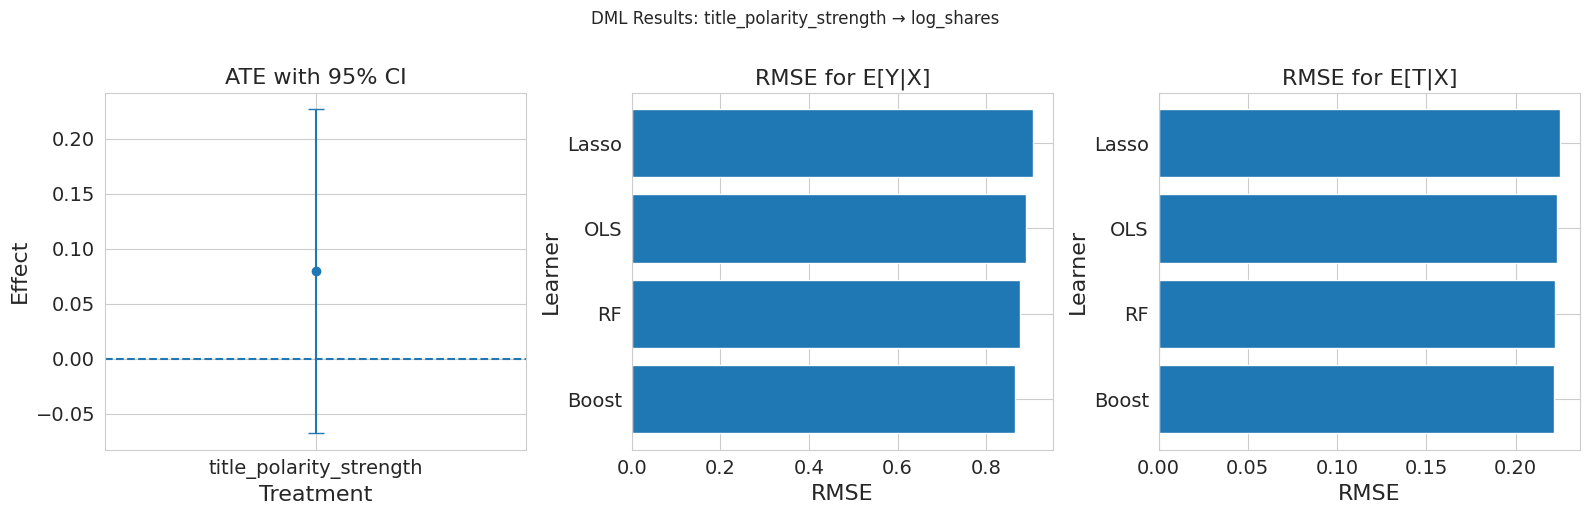

In [ ]:
plot_dml_results(res_title)

The estimated ATE is positive (around 0.08), suggesting that higher title polarity strength may increase log shares, but the 95% confidence interval crosses zero, indicating that the effect is not statistically significant.

In [ ]:
print("=== Final summary: Global Polarity===")
print(res_global["summary"])

print("\n=== RMSE for E[Y|X] ===")
print(res_global["rmse_y_df"])

print("\n=== RMSE for E[T|X] ===")
print(res_global["rmse_t_df"])

=== Final summary: Global Polarity===
      outcome                 treatment best_y best_t       ate    ci_low  \
0  log_shares  global_polarity_strength  Boost  Boost  0.041262 -0.681685   

    ci_high  n_obs  
0  0.764209  39644  

=== RMSE for E[Y|X] ===
  learner_y    rmse_y
0     Boost  0.864121
1        RF  0.876628
2       OLS  0.888873
3     Lasso  0.905771

=== RMSE for E[T|X] ===
  learner_t    rmse_t
0     Boost  0.072177
1        RF  0.074045
2       OLS  0.074565
3     Lasso  0.084169


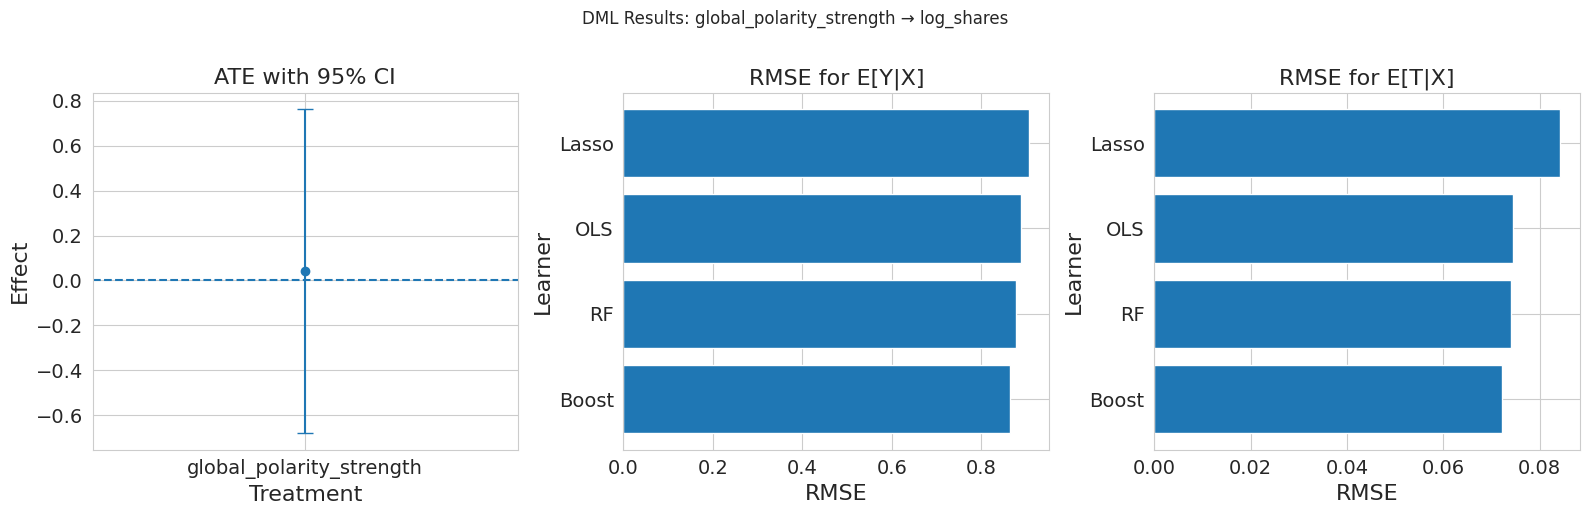

In [ ]:
plot_dml_results(res_global)

The estimated ATE for global polarity strength is close to zero, and the 95% confidence interval is very wide and clearly spans both negative and positive values, indicating a high level of uncertainty and no statistically significant effect on log shares.

Heterogeneity Analysis:

In [ ]:
df["is_positive_title"] = (df["title_sentiment_polarity"] > 0).astype(int)
df["is_positive_global"] = (df["global_sentiment_polarity"] > 0).astype(int)


# interaction term
df["title_strength_x_positive"] = (
    df["title_polarity_strength"] * df["is_positive_title"]
)

df["global_strength_x_positive"] = (
    df["global_polarity_strength"] * df["is_positive_global"]
)

In [ ]:
def extract_coef_and_ci(model):
    import numpy as np

    coef_vec = np.array(model.coef_).reshape(-1)
    ci_raw = model.coef__interval()

    beta1 = float(coef_vec[0])
    beta2 = float(coef_vec[1])

    if isinstance(ci_raw, tuple) and len(ci_raw) == 2:
        low = np.array(ci_raw[0]).reshape(-1)
        high = np.array(ci_raw[1]).reshape(-1)
        return {
            "beta1": beta1,
            "beta2": beta2,
            "beta1_low": float(low[0]),
            "beta1_high": float(high[0]),
            "beta2_low": float(low[1]),
            "beta2_high": float(high[1]),
        }

    ci_arr = np.array(ci_raw)

    if ci_arr.ndim == 2 and ci_arr.shape[0] == 2:
        return {
            "beta1": beta1,
            "beta2": beta2,
            "beta1_low": float(ci_arr[0, 0]),
            "beta1_high": float(ci_arr[1, 0]),
            "beta2_low": float(ci_arr[0, 1]),
            "beta2_high": float(ci_arr[1, 1]),
        }

    if ci_arr.ndim == 2 and ci_arr.shape[1] == 2:
        return {
            "beta1": beta1,
            "beta2": beta2,
            "beta1_low": float(ci_arr[0, 0]),
            "beta1_high": float(ci_arr[0, 1]),
            "beta2_low": float(ci_arr[1, 0]),
            "beta2_high": float(ci_arr[1, 1]),
        }

    if ci_arr.ndim == 3:
        ci_arr = ci_arr.reshape(-1, 2)
        return {
            "beta1": beta1,
            "beta2": beta2,
            "beta1_low": float(ci_arr[0, 0]),
            "beta1_high": float(ci_arr[0, 1]),
            "beta2_low": float(ci_arr[1, 0]),
            "beta2_high": float(ci_arr[1, 1]),
        }

    raise ValueError(f"Unexpected coef__interval() shape: {ci_arr.shape}")

def run_dml_interaction_pipeline(
    df,
    outcome_col,
    strength_col,
    positive_col,
    interaction_col,
    X_cols,
    learners_y,
    learners_t,
    n_splits=5,
    random_state=42,
    n_bootstrap=500
):
    """
    DML with 2-dimensional treatment:
      T1 = sentiment strength
      T2 = sentiment strength × positive indicator

    Interpretation:
      - coef on T1: effect of strength for the baseline group
      - coef on T2: extra effect for positive sentiment
      - positive total effect = T1 + T2
    """

    # ---------------------------------
    # STEP 1: prepare data
    # ---------------------------------
    needed_cols = [outcome_col, strength_col, positive_col, interaction_col] + X_cols
    dml_df = df[needed_cols].dropna().copy()

    # drop if strength=0
    dml_df = dml_df[dml_df[strength_col] > 0].copy()

    dml_df = dml_df.astype(float)

    Y = dml_df[outcome_col].to_numpy()
    X = dml_df[X_cols].to_numpy()

    # 2-dimensional treatment
    T = np.column_stack([
        dml_df[strength_col].to_numpy(),
        dml_df[interaction_col].to_numpy()
    ])

    # ---------------------------------
    # STEP 2: cross-validation scoring
    # ---------------------------------
    cv = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    def rmse_cv(model, X, y):
        preds = cross_val_predict(clone(model), X, y, cv=cv)
        return np.sqrt(mean_squared_error(y, preds))

    # Score Y models
    rmse_y_df = pd.DataFrame([
        {
            "learner_y": name,
            "rmse_y": rmse_cv(model, X, Y)
        }
        for name, model in learners_y.items()
    ]).sort_values("rmse_y").reset_index(drop=True)

    # Score T models
    rmse_t_rows = []
    for name, model in learners_t.items():
        rmse_t1 = rmse_cv(model, X, T[:, 0])
        rmse_t2 = rmse_cv(model, X, T[:, 1])
        rmse_t_avg = (rmse_t1 + rmse_t2) / 2

        rmse_t_rows.append({
            "learner_t": name,
            "rmse_t1": rmse_t1,
            "rmse_t2": rmse_t2,
            "rmse_t_avg": rmse_t_avg
        })

    rmse_t_df = pd.DataFrame(rmse_t_rows).sort_values("rmse_t_avg").reset_index(drop=True)

    best_y_name = rmse_y_df.loc[0, "learner_y"]
    best_t_name = rmse_t_df.loc[0, "learner_t"]

    # ---------------------------------
    # STEP 3: fit final DML
    # ---------------------------------

    best_model = DML(
        model_y=clone(learners_y[best_y_name]),
        model_t=MultiOutputRegressor(clone(learners_t[best_t_name])),
        model_final=LinearRegression(),
        discrete_treatment=False,
        random_state=random_state
    )

    best_model.fit(
        Y, T, X=X,
        inference=BootstrapInference(n_bootstrap_samples=n_bootstrap, n_jobs=-1)
    )
    print("coef_ =", best_model.coef_)
    print("coef__interval() =", best_model.coef__interval())
    # ---------------------------------
    # STEP 4: extract coefficients
    # ---------------------------------
    est = extract_coef_and_ci(best_model)

    beta_strength = est["beta1"]
    beta_interaction = est["beta2"]

    beta_strength_ci_low = est["beta1_low"]
    beta_strength_ci_high = est["beta1_high"]

    beta_inter_ci_low = est["beta2_low"]
    beta_inter_ci_high = est["beta2_high"]

    positive_total_effect = beta_strength + beta_interaction

    summary = pd.DataFrame([{
        "outcome": outcome_col,
        "strength_col": strength_col,
        "positive_col": positive_col,
        "interaction_col": interaction_col,
        "best_y": best_y_name,
        "best_t": best_t_name,
        "beta_strength_baseline": beta_strength,
        "beta_strength_ci_low": beta_strength_ci_low,
        "beta_strength_ci_high": beta_strength_ci_high,
        "beta_interaction_positive_extra": beta_interaction,
        "beta_inter_ci_low": beta_inter_ci_low,
        "beta_inter_ci_high": beta_inter_ci_high,
        "positive_total_effect": positive_total_effect,
        "n_obs": len(dml_df)
    }])

    return {
        "summary": summary,
        "rmse_y_df": rmse_y_df,
        "rmse_t_df": rmse_t_df,
        "model": best_model,
        "data_used": dml_df
    }

In [ ]:
res_title_inter = run_dml_interaction_pipeline(
    df=df,
    outcome_col="log_shares",
    strength_col="title_polarity_strength",
    positive_col="is_positive_title",
    interaction_col="title_strength_x_positive",
    X_cols=controls + topics,
    learners_y=learners_y,
    learners_t=learners_t
)

/usr/local/lib/python3.12/dist-packages/econml/dml/dml.py:192: UserWarning: The final model has a nonzero intercept for at least one outcome; it will be subtracted, but consider fitting a model without an intercept if possible.
  warn("The final model has a nonzero intercept for at least one outcome; "
/usr/local/lib/python3.12/dist-packages/econml/dml/dml.py:192: UserWarning: The final model has a nonzero intercept for at least one outcome; it will be subtracted, but consider fitting a model without an intercept if possible.
  warn("The final model has a nonzero intercept for at least one outcome; "
/usr/local/lib/python3.12/dist-packages/econml/dml/dml.py:192: UserWarning: The final model has a nonzero intercept for at least one outcome; it will be subtracted, but consider fitting a model without an intercept if possible.
  warn("The final model has a nonzero intercept for at least one outcome; "
/usr/local/lib/python3.12/dist-packages/econml/dml/dml.py:192: UserWarning: The final mo

coef_ = [[ 3.14934598e-01 -1.74485788e-05  9.63264625e-03  7.13733500e-03
   1.13831101e-01  1.05305260e-01 -7.50740317e-02  1.58042953e-03
  -3.04105087e-01  1.22375432e-01  1.21332619e-05 -4.53401224e-06
  -8.63690169e-04]
 [-2.15057792e-01  8.23100670e-05 -9.60758795e-03  5.11673768e-03
  -1.20877844e-01 -2.62148748e-01  2.41259220e-01  8.75550582e-02
   2.63510877e-01 -2.99286199e-02 -3.92933334e-05  4.30264163e-06
  -7.64845885e-04]]
coef__interval() = (array([[-4.27325578e-01, -2.56011508e-04, -3.30895713e-03,
        -1.43947153e-02, -8.89155303e-02, -1.35066671e-01,
        -3.19114397e-01, -2.16229988e-01, -6.21134564e-01,
        -1.20146910e-01, -4.35614314e-05, -1.04879068e-05,
        -9.36004233e-03],
       [-9.11790582e-01, -5.02945337e-05, -1.91847119e-02,
        -1.27663459e-02, -3.32153902e-01, -5.58809939e-01,
        -8.41707540e-05, -1.20888839e-01,  6.32606462e-02,
        -2.84940315e-01, -1.30629299e-04,  1.53151167e-06,
        -8.42085239e-03]]), array([[ 1.

In [ ]:
res_global_inter = run_dml_interaction_pipeline(
    df=df,
    outcome_col="log_shares",
    strength_col="global_polarity_strength",
    positive_col="is_positive_global",
    interaction_col="global_strength_x_positive",
    X_cols=controls + topics,
    learners_y=learners_y,
    learners_t=learners_t
)

/usr/local/lib/python3.12/dist-packages/econml/dml/dml.py:192: UserWarning: The final model has a nonzero intercept for at least one outcome; it will be subtracted, but consider fitting a model without an intercept if possible.
  warn("The final model has a nonzero intercept for at least one outcome; "
/usr/local/lib/python3.12/dist-packages/econml/dml/dml.py:192: UserWarning: The final model has a nonzero intercept for at least one outcome; it will be subtracted, but consider fitting a model without an intercept if possible.
  warn("The final model has a nonzero intercept for at least one outcome; "
/usr/local/lib/python3.12/dist-packages/econml/dml/dml.py:192: UserWarning: The final model has a nonzero intercept for at least one outcome; it will be subtracted, but consider fitting a model without an intercept if possible.
  warn("The final model has a nonzero intercept for at least one outcome; "
/usr/local/lib/python3.12/dist-packages/econml/dml/dml.py:192: UserWarning: The final mo

coef_ = [[-1.07006497e+00  6.24526267e-04  2.22424470e-02 -1.35099022e-01
  -6.23371604e-01 -1.30827551e-01  6.51025831e-01 -8.05305419e-01
   1.54882732e+00 -6.95686852e-01 -1.79821435e-04 -7.15994821e-06
  -9.63677443e-03]
 [ 8.91130127e-01 -5.54534466e-05 -1.96405806e-02  1.63790621e-01
   4.71431235e-01 -2.12906857e-01  6.15401227e-02  9.08235064e-01
  -1.48480264e+00  1.80750609e-01  1.57410079e-04  1.02133617e-05
  -4.81363780e-03]]
coef__interval() = (array([[-4.41596142e+00, -1.24219426e-03, -5.03729870e-03,
        -3.60607712e-01, -1.61881340e+00, -1.91997337e+00,
        -1.01795791e+00, -2.40478493e+00, -1.98296385e-01,
        -2.47482718e+00, -7.51708564e-04, -3.31040229e-05,
        -5.21818952e-02],
       [-3.78845701e+00, -1.45542445e-03, -6.27637500e-02,
         1.00746287e-01, -7.99744231e-01, -2.63602273e+00,
        -1.35835808e+00, -1.23945136e-01, -3.04030737e+00,
        -1.53198969e+00, -3.09387345e-04, -7.69204135e-06,
        -4.72916152e-02]]), array([[ 3.

In [ ]:
print("=== Title interaction summary ===")
print(res_title_inter["summary"])

print("\n=== RMSE for E[Y|X] ===")
print(res_title_inter["rmse_y_df"])

print("\n=== RMSE for E[T|X] ===")
print(res_title_inter["rmse_t_df"])

=== Title interaction summary ===
      outcome             strength_col       positive_col  \
0  log_shares  title_polarity_strength  is_positive_title   

             interaction_col best_y best_t  beta_strength_baseline  \
0  title_strength_x_positive  Boost  Boost                0.314935   

   beta_strength_ci_low  beta_strength_ci_high  \
0             -0.427326               1.043777   

   beta_interaction_positive_extra  beta_inter_ci_low  beta_inter_ci_high  \
0                        -0.000017          -0.000256            0.000161   

   positive_total_effect  n_obs  
0               0.314917  19730  

=== RMSE for E[Y|X] ===
  learner_y    rmse_y
0     Boost  0.882173
1        RF  0.890149
2       OLS  0.903103
3     Lasso  0.919232

=== RMSE for E[T|X] ===
  learner_t   rmse_t1   rmse_t2  rmse_t_avg
0     Boost  0.224762  0.238688    0.231725
1        RF  0.225112  0.238971    0.232042
2       OLS  0.227226  0.241132    0.234179
3     Lasso  0.229602  0.243001    0.23630

In [ ]:
print("=== Global interaction summary ===")
print(res_global_inter["summary"])

print("\n=== RMSE for E[Y|X] ===")
print(res_global_inter["rmse_y_df"])

print("\n=== RMSE for E[T|X] ===")
print(res_global_inter["rmse_t_df"])

=== Global interaction summary ===
      outcome              strength_col        positive_col  \
0  log_shares  global_polarity_strength  is_positive_global   

              interaction_col best_y best_t  beta_strength_baseline  \
0  global_strength_x_positive  Boost  Boost               -1.070065   

   beta_strength_ci_low  beta_strength_ci_high  \
0             -4.415961               3.789791   

   beta_interaction_positive_extra  beta_inter_ci_low  beta_inter_ci_high  \
0                         0.000625          -0.001242            0.001986   

   positive_total_effect  n_obs  
0               -1.06944  38447  

=== RMSE for E[Y|X] ===
  learner_y    rmse_y
0     Boost  0.858167
1        RF  0.870457
2       OLS  0.881769
3     Lasso  0.900597

=== RMSE for E[T|X] ===
  learner_t   rmse_t1   rmse_t2  rmse_t_avg
0     Boost  0.073148  0.077545    0.075346
1        RF  0.075049  0.079297    0.077173
2       OLS  0.075608  0.079904    0.077756
3     Lasso  0.081928  0.086088    

In [ ]:
def plot_interaction_ci(res_inter, title="Interaction Effects with 95% CI"):
    s = res_inter["summary"].iloc[0]

    plot_df = pd.DataFrame({
        "effect": [
            "Baseline (negative)",
            "Positive extra",
            "Positive total"
        ],
        "value": [
            s["beta_strength_baseline"],
            s["beta_interaction_positive_extra"],
            s["positive_total_effect"]
        ],
        "ci_low": [
            s["beta_strength_ci_low"],
            s["beta_inter_ci_low"],
            # total effect CI
            s["beta_strength_ci_low"] + s["beta_inter_ci_low"]
        ],
        "ci_high": [
            s["beta_strength_ci_high"],
            s["beta_inter_ci_high"],
            s["beta_strength_ci_high"] + s["beta_inter_ci_high"]
        ]
    })

    plot_df["err_low"] = plot_df["value"] - plot_df["ci_low"]
    plot_df["err_high"] = plot_df["ci_high"] - plot_df["value"]

    fig, ax = plt.subplots(figsize=(8, 5), dpi=200)

    y_pos = range(len(plot_df))

    ax.errorbar(
        x=plot_df["value"],
        y=y_pos,
        xerr=[plot_df["err_low"], plot_df["err_high"]],
        fmt='o',
        capsize=4,
        elinewidth=1.5,
        markersize=6
    )

    ax.axvline(0, linestyle='--', linewidth=1)

    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(plot_df["effect"], fontsize=11)

    ax.set_xlabel("Estimated effect on popularity", fontsize=12)
    ax.set_title(title, fontsize=13)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


    for i, row in plot_df.iterrows():
        ax.text(
            row["ci_high"] + 0.0005,
            i,
            f'{row["value"]:.3f}\n[{row["ci_low"]:.3f}, {row["ci_high"]:.3f}]',
            va="center",
            fontsize=9
        )

    plt.tight_layout()
    plt.show()

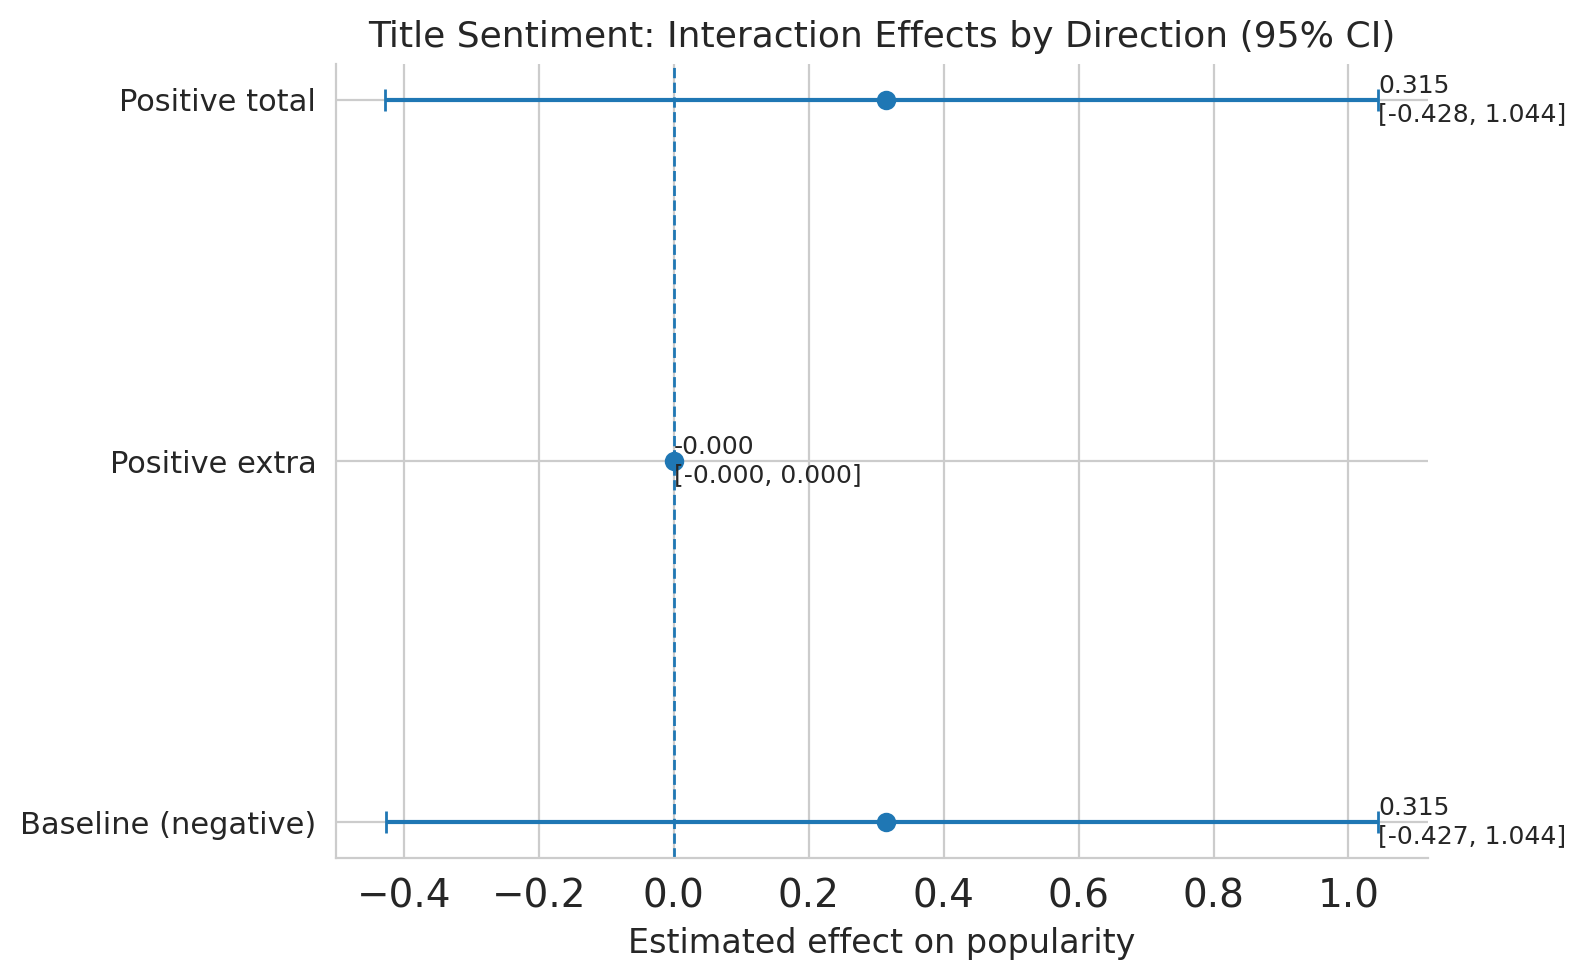

In [ ]:
plot_interaction_ci(
    res_title_inter,
    title="Title Sentiment: Interaction Effects by Direction (95% CI)"
)

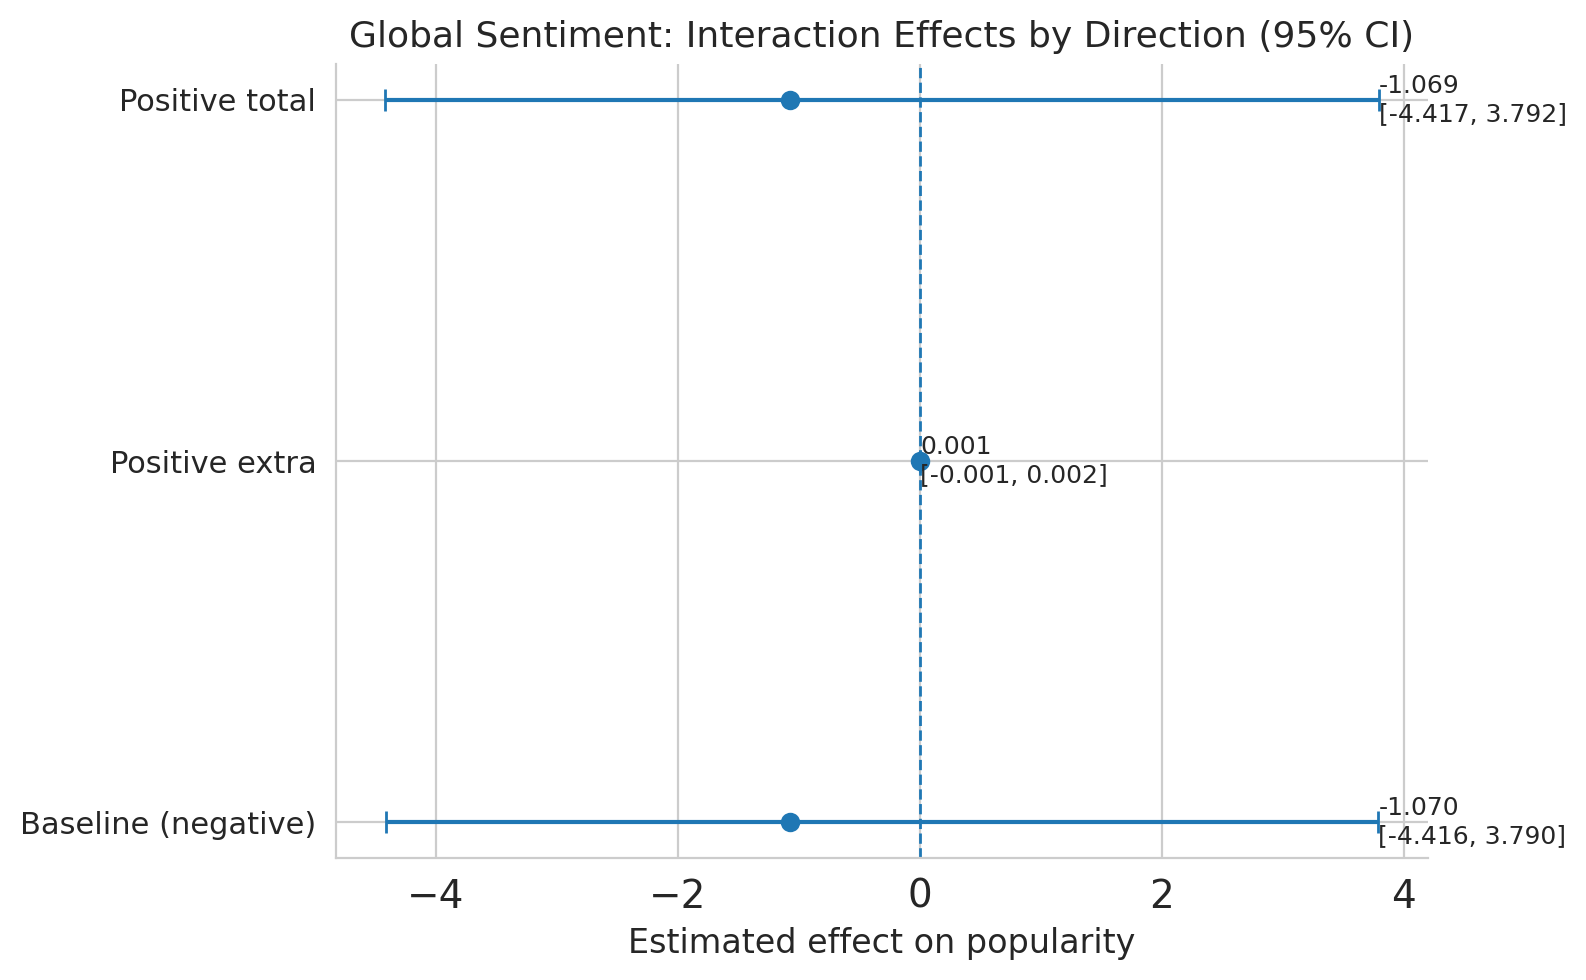

In [ ]:
plot_interaction_ci(
    res_global_inter,
    title="Global Sentiment: Interaction Effects by Direction (95% CI)"
)

Across both plots, there is no statistically significant interaction effect of sentiment direction on popularity.
- For title sentiment, both the baseline (negative) and positive total effects are positive (\~0.315) but have wide confidence intervals that cross zero, while the “positive extra” effect is essentially zero, indicating no additional impact from being positive beyond the baseline.
- For global sentiment, estimates are even more uncertain: both baseline and positive total effects are negative (\~−1.07) with extremely wide confidence intervals spanning large negative to positive values, and again the “positive extra” effect is near zero.
Overall, these results suggest no reliable evidence that sentiment direction (positive vs negative) meaningfully changes the effect on popularity, and any observed differences are driven by noise rather than a true interaction.